# HealthSense AI — V5 Visual Review & External Validation

## Mục tiêu

Notebook này dành cho **V5 frozen single-domain/external-validation pipeline**.

Nó ưu tiên **visualization + reproducibility**, không viết lại logic AI. Các cell sử dụng:

- model `.pkl` V5 đã có;
- code `.py` trong `src/healthsense_ml/`;
- scripts trong `experiments/06_external_validation/`;
- prediction CSV đã sinh từ các scripts đó nếu có.

> Đây là module **screening AF từ PPG**, không phải ECG-confirmed diagnosis.

In [1]:
from pathlib import Path
import sys
import json
import subprocess
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
)

warnings.filterwarnings("ignore", category=UserWarning)

def find_repo_root():
    candidates = [
        Path.cwd(),
        Path("/home/phuc/Documents/HealthSense_rungtamnhi"),
        Path.cwd().parent,
    ]
    for p in candidates:
        if (p / "src/healthsense_ml").exists():
            return p.resolve()
    raise FileNotFoundError(
        "Không tìm thấy HealthSense repo. "
        "Hãy cd vào /home/phuc/Documents/HealthSense_rungtamnhi "
        "hoặc sửa REPO thủ công."
    )

REPO = find_repo_root()
print("REPO =", REPO)

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

REPO = /home/phuc/Documents/HealthSense_rungtamnhi


In [2]:
def run_script(relative_path, *args, check=True):
    script = REPO / relative_path
    if not script.exists():
        raise FileNotFoundError(script)
    cmd = [sys.executable, str(script), *map(str, args)]
    print(">", " ".join(cmd))
    return subprocess.run(cmd, cwd=REPO, check=check)

def first_existing(paths):
    for p in paths:
        p = REPO / p
        if p.exists():
            return p
    return None

PROBABILITY_CANDIDATES = [
    "af_probability",
    "meta_probability",
    "stack_probability",
    "probability",
    "prob_af",
    "prob_v5",
    "v5_probability",
    "y_prob",
    "pred_proba",
]

def infer_probability_column(df):
    return next((c for c in PROBABILITY_CANDIDATES if c in df.columns), None)

def normalize_v5_binary_target(df, dataset_name):
    """
    Return a copy with canonical binary target `af_binary`.

    IMPORTANT:
    V5 external datasets do not all use the same label schema.
    In particular PulseWatch may contain NSR / AF / PAC_PVC as
    separate labels. It must be converted to AF-vs-all before
    binary AUROC/PR-AUC/Brier are computed.
    """
    d = df.copy()
    name = dataset_name.lower()

    # Prefer explicit rhythm/class strings whenever available.
    for col in ["class_name", "rhythm"]:
        if col in d.columns:
            s = d[col].astype(str).str.upper().str.strip()
            d["af_binary"] = s.eq("AF").astype(int)
            return d, f"{col} == AF"

    # Explicit binary columns are safer than a generic label.
    for col in ["binary_label_clean", "binary_label", "label_eval", "label_v7", "y_true", "gt"]:
        if col in d.columns:
            y = pd.to_numeric(d[col], errors="coerce")
            vals = set(y.dropna().unique().tolist())
            if vals.issubset({0, 1}):
                d["af_binary"] = y.astype("Int64")
                return d, col

    if "label" in d.columns:
        y = pd.to_numeric(d["label"], errors="coerce")
        vals = set(y.dropna().unique().tolist())

        # DeepBeat / Liu canonical prediction files should already be binary.
        if vals.issubset({0, 1}):
            d["af_binary"] = y.astype("Int64")
            return d, "label (already binary)"

        # PulseWatch V5 schema used label==1 for AF and another class for PAC/PVC.
        # This explicit conversion is the key fix for the original notebook error.
        if "pulsewatch" in name and 1 in vals:
            d["af_binary"] = y.eq(1).astype("Int64")
            return d, "PulseWatch label == 1 (AF), others non-AF"

    raise ValueError(
        f"Cannot safely derive AF-vs-all binary target for {dataset_name}. "
        f"Available columns: {list(d.columns)}"
    )

def binary_metrics(y, p, threshold=0.5):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    unique = np.unique(y)
    if not set(unique).issubset({0, 1}):
        raise ValueError(f"binary_metrics expected labels {{0,1}}, got {unique}")

    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()

    return {
        "AUROC": roc_auc_score(y, p) if len(unique) == 2 else np.nan,
        "PR_AUC": average_precision_score(y, p) if np.any(y == 1) else np.nan,
        "Brier": brier_score_loss(y, p),
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "Sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "Specificity": tn / (tn + fp) if tn + fp else np.nan,
    }

def plot_roc_pr(df, label_col, prob_col, title):
    y = df[label_col].astype(int).to_numpy()
    p = df[prob_col].astype(float).to_numpy()

    fig = plt.figure(figsize=(7, 5))
    fpr, tpr, _ = roc_curve(y, p)
    plt.plot(fpr, tpr, label=f"AUROC={roc_auc_score(y,p):.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"{title} — ROC")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    fig = plt.figure(figsize=(7, 5))
    precision, recall, _ = precision_recall_curve(y, p)
    plt.plot(recall, precision, label=f"PR-AUC={average_precision_score(y,p):.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} — Precision–Recall")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

def plot_probability_distribution(df, label_col, prob_col, title):
    fig = plt.figure(figsize=(8, 5))
    for label in sorted(df[label_col].dropna().unique()):
        vals = df.loc[df[label_col] == label, prob_col].astype(float)
        plt.hist(vals, bins=35, alpha=0.45, density=True, label=f"AF={label}")
    plt.xlabel("AF probability")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

def plot_confusion(y, pred, title):
    cm = confusion_matrix(y, pred, labels=[0, 1])
    fig = plt.figure(figsize=(5.5, 5))
    plt.imshow(cm)
    plt.xticks([0,1], ["Pred non-AF", "Pred AF"])
    plt.yticks([0,1], ["True non-AF", "True AF"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.title(title)
    plt.xlabel("Prediction")
    plt.ylabel("Ground truth")
    plt.colorbar()
    plt.show()


## 1. Kiểm tra frozen V5 model

In [3]:
V5_MODEL = REPO / "models/mimic/healthsense_af_v5_rf_ac_frozen.pkl"
assert V5_MODEL.exists(), V5_MODEL

v5 = joblib.load(V5_MODEL)
print(v5)
print("\nModel size:", V5_MODEL.stat().st_size / 1024 / 1024, "MiB")

if hasattr(v5, "named_steps"):
    print("\nPipeline steps:")
    for k, v in v5.named_steps.items():
        print(" -", k, ":", v)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(max_depth=10, n_jobs=-1,
                                        random_state=42))])

Model size: 1.0402240753173828 MiB

Pipeline steps:
 - scaler : StandardScaler()
 - clf : RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)


## 2. Frozen 14-feature contract

In [4]:
V5_FEATURES = [
    "HR_mean", "Mean_NN", "SDNN", "RMSSD", "NN50", "pNN50", "CV",
    "HF", "Total_Power", "HF_norm", "SD1", "SD2", "SampEn", "PPG_AC"
]

pd.DataFrame({
    "order": np.arange(1, len(V5_FEATURES)+1),
    "feature": V5_FEATURES
})

,order,feature
0,1,HR_mean
1,2,Mean_NN
2,3,SDNN
3,4,RMSSD
4,5,NN50
5,6,pNN50
6,7,CV
7,8,HF
8,9,Total_Power
9,10,HF_norm


## 3. Import trực tiếp code feature extraction hiện có

In [5]:
from src.healthsense_ml.signal_processing import extract_nn_series
from src.healthsense_ml.hrv_features import compute_hrv_features

print("extract_nn_series:", extract_nn_series)
print("compute_hrv_features:", compute_hrv_features)
print("\nNotebook không re-implement hai hàm này; nó dùng trực tiếp code .py của repo.")

extract_nn_series: <function extract_nn_series at 0x70f6cc24be20>
compute_hrv_features: <function compute_hrv_features at 0x70f6cc04a160>

Notebook không re-implement hai hàm này; nó dùng trực tiếp code .py của repo.


## 4. Kiểm tra các scripts V5 external validation hiện có

In [6]:
V5_SCRIPTS = [
    "experiments/06_external_validation/deepbeat_frozen_v5_external.py",
    "experiments/06_external_validation/pulsewatch_frozen_v5_external.py",
    "experiments/06_external_validation/liu_pseudo30_frozen_v5.py",
    "experiments/06_external_validation/peakdet_pac_pvc_frozen_v5.py",
]

for s in V5_SCRIPTS:
    p = REPO / s
    print(("OK  " if p.exists() else "MISS"), s)

OK   experiments/06_external_validation/deepbeat_frozen_v5_external.py
OK   experiments/06_external_validation/pulsewatch_frozen_v5_external.py
OK   experiments/06_external_validation/liu_pseudo30_frozen_v5.py
OK   experiments/06_external_validation/peakdet_pac_pvc_frozen_v5.py


### Tùy chọn chạy lại scripts

Mặc định **không chạy lại** vì có thể tốn thời gian và ghi đè artifact. Chỉ đổi `RUN_V5_EXTERNAL = True` khi muốn reproduce.

In [7]:
RUN_V5_EXTERNAL = False

if RUN_V5_EXTERNAL:
    for script in V5_SCRIPTS:
        if (REPO / script).exists():
            run_script(script)

## 5. Tự động tìm V5 prediction CSVs

In [8]:
V5_CANONICAL_SPECS = {
    "DeepBeat": [
        "experiments/06_external_validation/deepbeat_frozen_v5_predictions.csv",
    ],
    "PulseWatch": [
        "experiments/06_external_validation/pulsewatch_frozen_v5_predictions.csv",
    ],
    "Liu": [
        "experiments/06_external_validation/liu_pseudo30_frozen_v5_predictions.csv",
    ],
    "PeakDet PAC/PVC": [
        "experiments/06_external_validation/peakdet_pac_pvc_frozen_v5_predictions.csv",
    ],
}

inventory_rows = []

for dataset, rel_paths in V5_CANONICAL_SPECS.items():
    path = first_existing(rel_paths)

    if path is None:
        inventory_rows.append({
            "dataset": dataset,
            "file": None,
            "exists": False,
            "rows": np.nan,
            "probability_col": None,
            "target_rule": None,
        })
        continue

    df0 = pd.read_csv(path, low_memory=False)
    prob_col = infer_probability_column(df0)

    target_rule = None
    if dataset != "PeakDet PAC/PVC":
        try:
            _, target_rule = normalize_v5_binary_target(df0, dataset)
        except Exception as e:
            target_rule = f"ERROR: {e}"

    inventory_rows.append({
        "dataset": dataset,
        "file": str(path.relative_to(REPO)),
        "exists": True,
        "rows": len(df0),
        "probability_col": prob_col,
        "target_rule": target_rule,
    })

v5_inventory = pd.DataFrame(inventory_rows)
display(v5_inventory)

print(
    "\nLưu ý: notebook cố ý KHÔNG auto-plot mọi CSV trong experiments/06_external_validation.\n"
    "Folder này có nhiều audit/SQI/subject-summary CSV với semantics khác nhau; "
    "tự suy đoán chỉ từ tên cột có thể tạo metric sai."
)


,dataset,file,exists,rows,probability_col,target_rule
0,DeepBeat,experiments/06_external_validation/deepbeat_fr...,True,15605,af_probability,rhythm == AF
1,PulseWatch,experiments/06_external_validation/pulsewatch_...,True,156978,af_probability,class_name == AF
2,Liu,experiments/06_external_validation/liu_pseudo3...,True,6280,af_probability,rhythm == AF
3,PeakDet PAC/PVC,experiments/06_external_validation/peakdet_pac...,True,50,af_probability,NaN



Lưu ý: notebook cố ý KHÔNG auto-plot mọi CSV trong experiments/06_external_validation.
Folder này có nhiều audit/SQI/subject-summary CSV với semantics khác nhau; tự suy đoán chỉ từ tên cột có thể tạo metric sai.


## 6. Visualize canonical V5 AF-vs-all predictions

### Fix so với notebook trước

Notebook cũ suy đoán rằng bất kỳ file nào có `label + af_probability` đều là binary AF task.

Điều đó sai với **PulseWatch**, vì `label` có nhiều lớp (NSR / AF / PAC-PVC).  
Khi truyền multiclass `y_true` cùng một vector probability AF vào `average_precision_score`, sklearn báo:

`ValueError: y_score needs to be of shape (n_samples, n_classes)`

Bản này chuẩn hóa target theo từng dataset trước khi tính metric:

- DeepBeat: binary label có sẵn.
- PulseWatch: `class_name == AF` nếu có; fallback lịch sử là `label == 1`.
- Liu: ưu tiên `rhythm == AF` / binary label.
- PeakDet: không tính AUROC/PR-AUC vì challenge này chỉ có PAC/PVC non-AF.



DeepBeat
file: /home/phuc/Documents/HealthSense_rungtamnhi/experiments/06_external_validation/deepbeat_frozen_v5_predictions.csv
target: rhythm == AF
probability: af_probability
class counts: {0: 12135, 1: 3470}
AUROC             0.719057
PR_AUC            0.426598
Brier             0.242015
TP             2375.000000
TN             7677.000000
FP             4458.000000
FN             1095.000000
Sensitivity       0.684438
Specificity       0.632633
dtype: float64


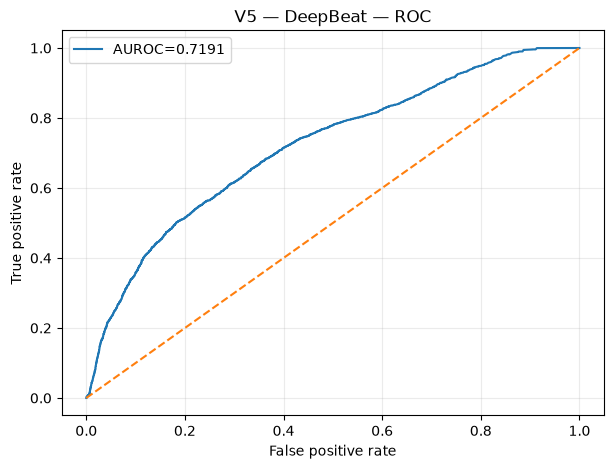

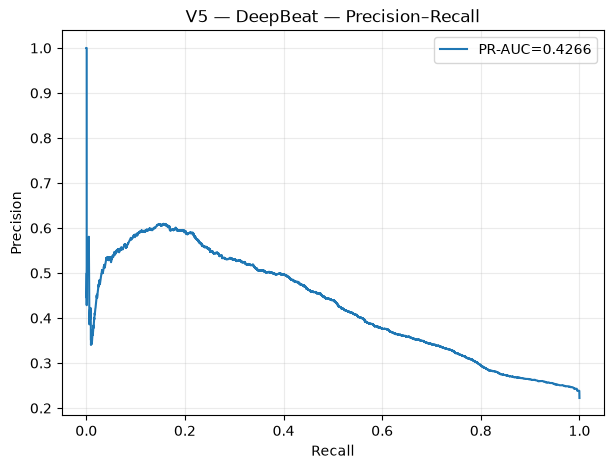

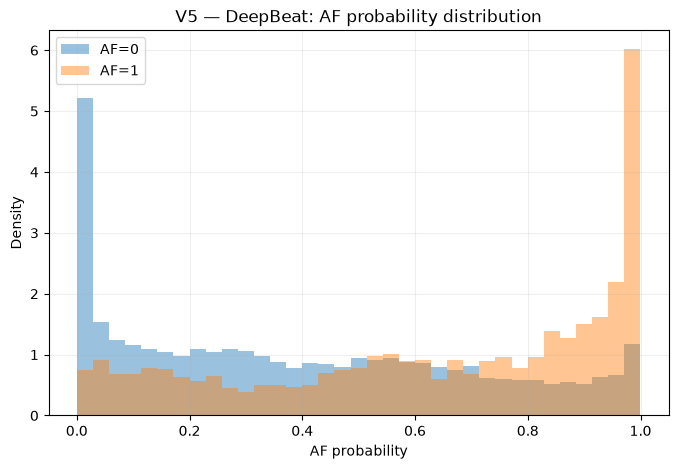

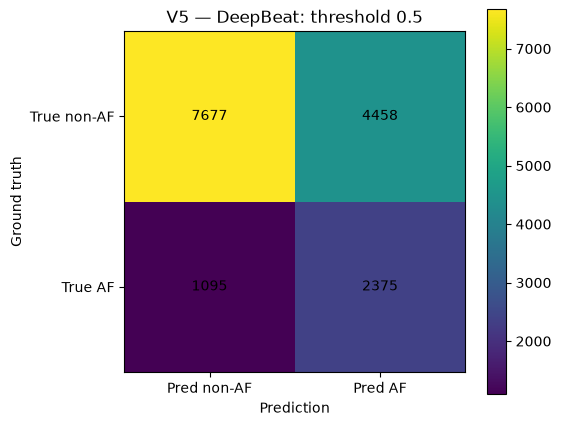


PulseWatch
file: /home/phuc/Documents/HealthSense_rungtamnhi/experiments/06_external_validation/pulsewatch_frozen_v5_predictions.csv
target: class_name == AF
probability: af_probability
class counts: {0: 132937, 1: 24041}
AUROC               0.986078
PR_AUC              0.924700
Brier               0.050277
TP              23298.000000
TN             123037.000000
FP               9900.000000
FN                743.000000
Sensitivity         0.969094
Specificity         0.925529
dtype: float64


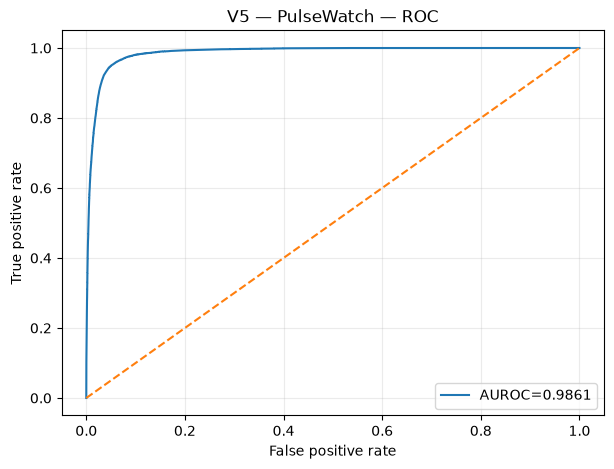

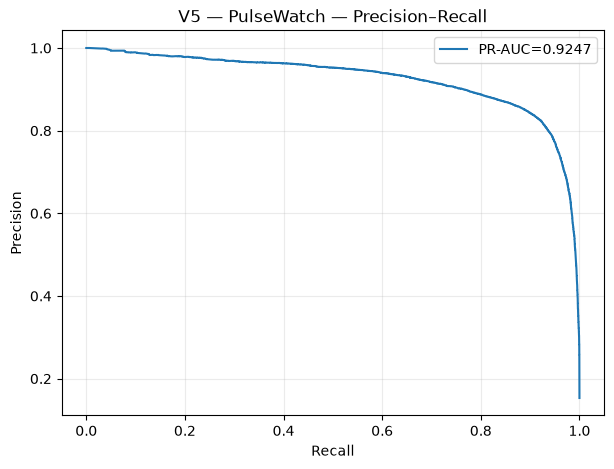

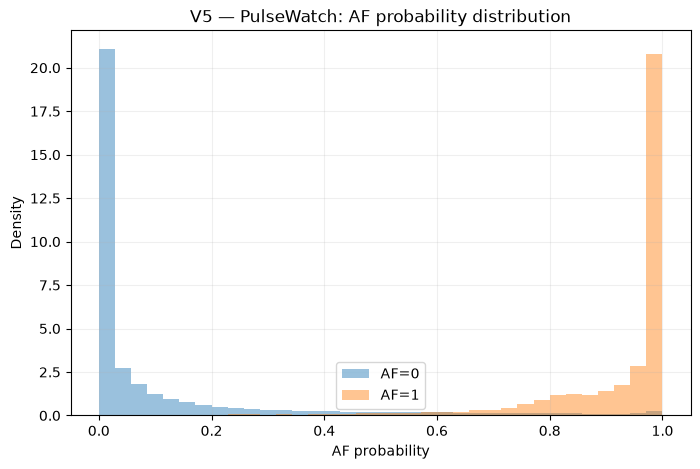

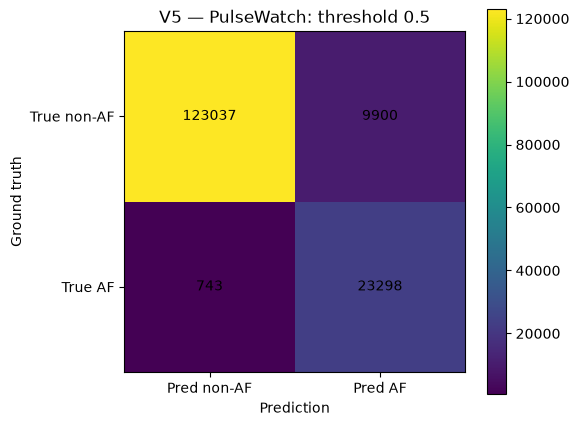


Liu
file: /home/phuc/Documents/HealthSense_rungtamnhi/experiments/06_external_validation/liu_pseudo30_frozen_v5_predictions.csv
target: rhythm == AF
probability: af_probability
class counts: {0: 3568, 1: 2712}
AUROC             0.967877
PR_AUC            0.927168
Brier             0.085136
TP             2691.000000
TN             2898.000000
FP              670.000000
FN               21.000000
Sensitivity       0.992257
Specificity       0.812220
dtype: float64


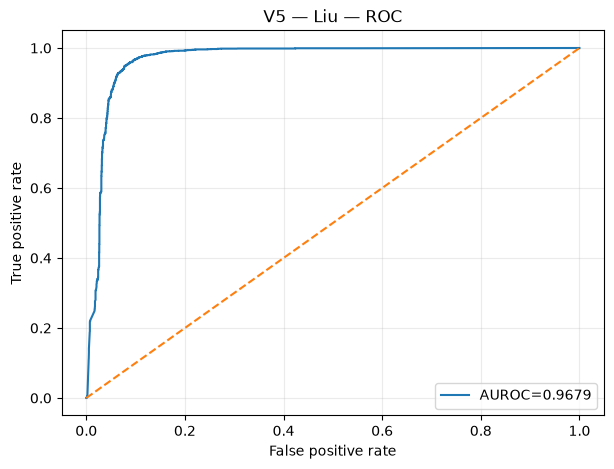

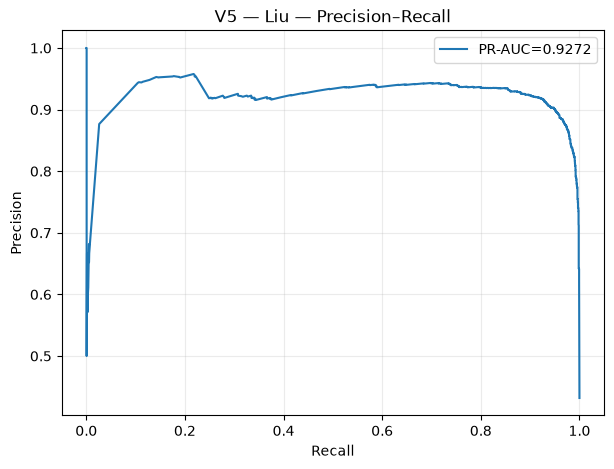

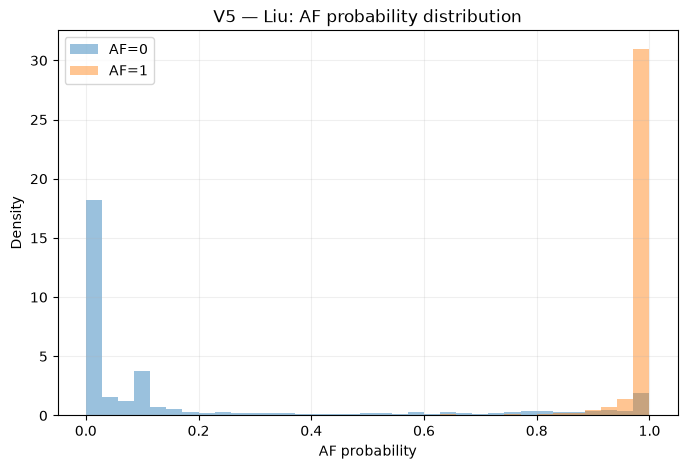

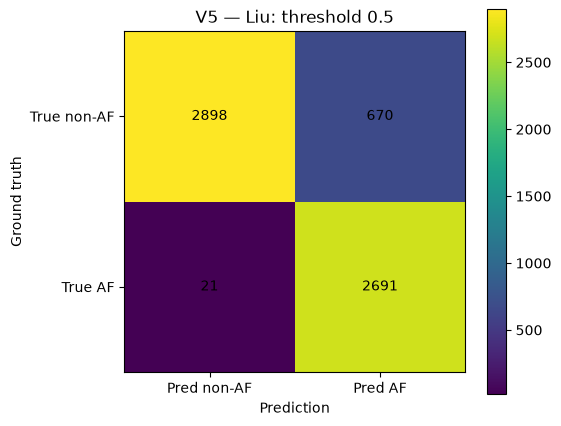

,dataset,file,n,target_rule,AUROC,PR_AUC,Brier,TP,TN,FP,FN,Sensitivity,Specificity
0,DeepBeat,deepbeat_frozen_v5_predictions.csv,15605,rhythm == AF,0.719057,0.426598,0.242015,2375,7677,4458,1095,0.684438,0.632633
1,PulseWatch,pulsewatch_frozen_v5_predictions.csv,156978,class_name == AF,0.986078,0.924700,0.050277,23298,123037,9900,743,0.969094,0.925529
2,Liu,liu_pseudo30_frozen_v5_predictions.csv,6280,rhythm == AF,0.967877,0.927168,0.085136,2691,2898,670,21,0.992257,0.812220


In [9]:
dataset_frames = {}
metric_rows = []

for dataset in ["DeepBeat", "PulseWatch", "Liu"]:
    spec = v5_inventory[v5_inventory["dataset"] == dataset]
    if spec.empty or not bool(spec.iloc[0]["exists"]):
        print("MISS:", dataset)
        continue

    path = REPO / spec.iloc[0]["file"]
    df = pd.read_csv(path, low_memory=False)

    prob_col = infer_probability_column(df)
    if prob_col is None:
        print(f"SKIP {dataset}: không tìm thấy probability column")
        continue

    try:
        d, target_rule = normalize_v5_binary_target(df, dataset)
    except Exception as e:
        print(f"SKIP {dataset}: {e}")
        continue

    d[prob_col] = pd.to_numeric(d[prob_col], errors="coerce")
    d["af_binary"] = pd.to_numeric(d["af_binary"], errors="coerce")

    valid = (
        d["af_binary"].isin([0, 1])
        & np.isfinite(d[prob_col])
    )
    d = d.loc[valid].copy()

    if d["af_binary"].nunique() != 2:
        print(f"SKIP {dataset}: sau normalize không còn đủ 2 class")
        continue

    dataset_frames[dataset] = {
        "df": d,
        "prob_col": prob_col,
        "target_rule": target_rule,
        "source_file": path,
    }

    m = binary_metrics(d["af_binary"], d[prob_col], threshold=0.5)
    metric_rows.append({
        "dataset": dataset,
        "file": path.name,
        "n": len(d),
        "target_rule": target_rule,
        **m,
    })

    print("\n" + "="*90)
    print(dataset)
    print("file:", path)
    print("target:", target_rule)
    print("probability:", prob_col)
    print("class counts:", d["af_binary"].value_counts().sort_index().to_dict())
    print(pd.Series(m))

    plot_roc_pr(d, "af_binary", prob_col, f"V5 — {dataset}")
    plot_probability_distribution(
        d, "af_binary", prob_col,
        f"V5 — {dataset}: AF probability distribution"
    )

    pred = (d[prob_col].to_numpy() >= 0.5).astype(int)
    plot_confusion(
        d["af_binary"].astype(int).to_numpy(),
        pred,
        f"V5 — {dataset}: threshold 0.5"
    )

v5_metrics = pd.DataFrame(metric_rows)
display(v5_metrics)


## 7. Cross-dataset overview

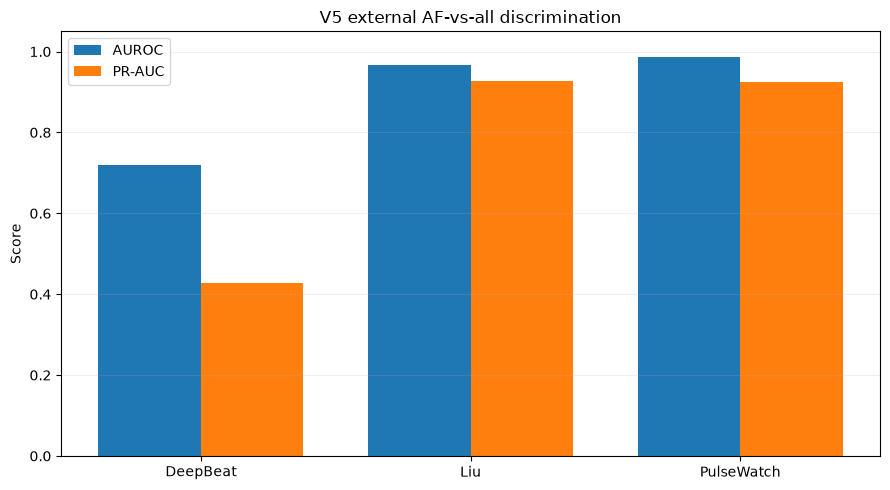

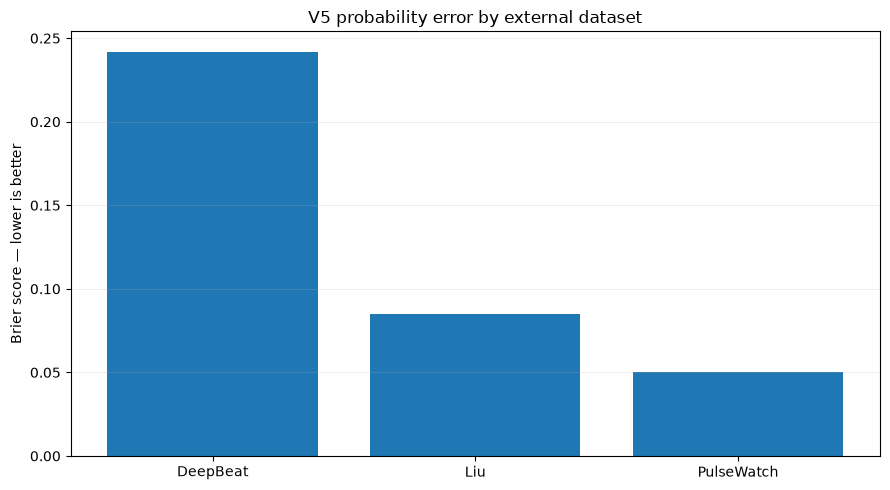

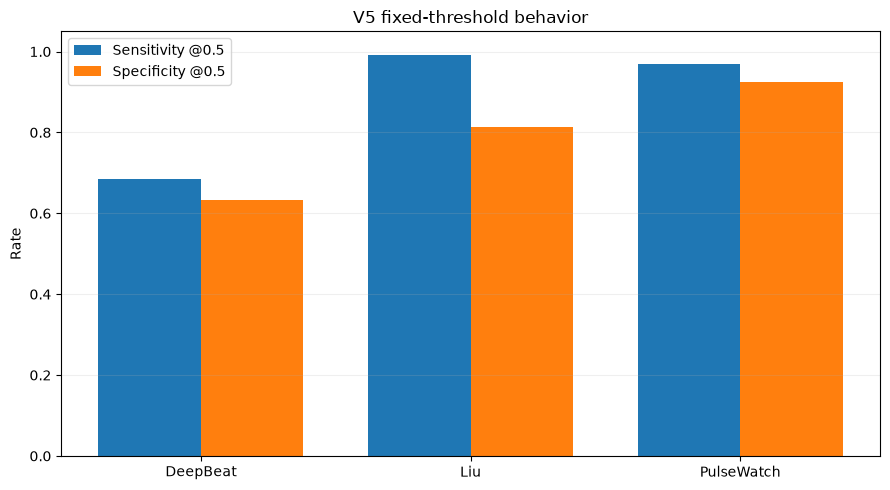

In [10]:
if "v5_metrics" in globals() and not v5_metrics.empty:
    plot_df = v5_metrics.sort_values("AUROC").copy()

    fig = plt.figure(figsize=(9, 5))
    x = np.arange(len(plot_df))
    width = 0.38
    plt.bar(x - width/2, plot_df["AUROC"], width, label="AUROC")
    plt.bar(x + width/2, plot_df["PR_AUC"], width, label="PR-AUC")
    plt.xticks(x, plot_df["dataset"])
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("V5 external AF-vs-all discrimination")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(9, 5))
    plt.bar(plot_df["dataset"], plot_df["Brier"])
    plt.ylabel("Brier score — lower is better")
    plt.title("V5 probability error by external dataset")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(9, 5))
    x = np.arange(len(plot_df))
    plt.bar(x - width/2, plot_df["Sensitivity"], width, label="Sensitivity @0.5")
    plt.bar(x + width/2, plot_df["Specificity"], width, label="Specificity @0.5")
    plt.xticks(x, plot_df["dataset"])
    plt.ylim(0, 1.05)
    plt.ylabel("Rate")
    plt.title("V5 fixed-threshold behavior")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


## 8. PAC/PVC hard-negative view

file: /home/phuc/Documents/HealthSense_rungtamnhi/experiments/06_external_validation/peakdet_pac_pvc_frozen_v5_predictions.csv
probability column: af_probability
rows: 50


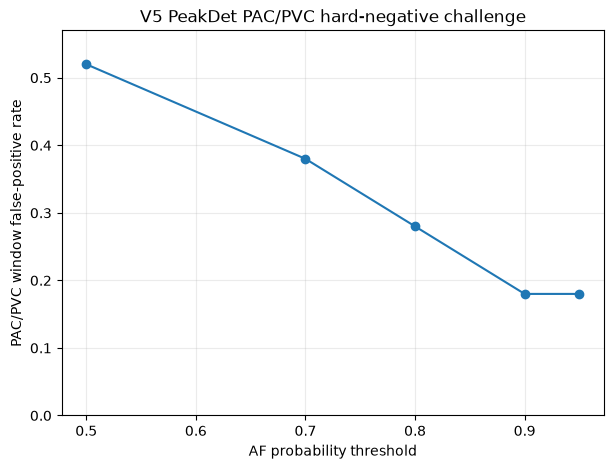

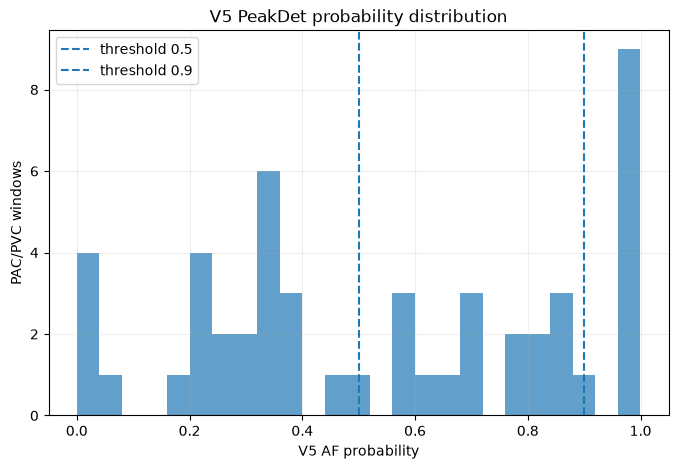

,threshold,false_positive_windows,window_FPR
0,0.50,26,0.52
1,0.70,19,0.38
2,0.80,14,0.28
3,0.90,9,0.18
4,0.95,9,0.18



PulseWatch probability by class_name


,class_name,count,mean,median
0,AF,24041,0.918097,0.987177
1,PAC_PVC,13364,0.368231,0.290000
2,NSR,119573,0.077007,0.000000


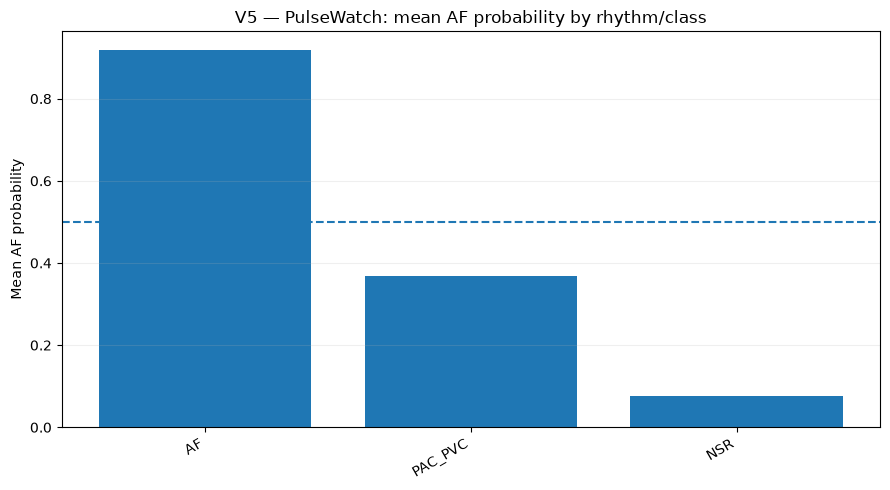


Liu probability by rhythm


,rhythm,count,mean,median
0,AF,2712,0.978688,0.998305
1,PAC,234,0.641702,0.717730
2,PVC,410,0.487999,0.482072
3,VT,185,0.438913,0.263627
4,SVT,922,0.281282,0.100000
5,SR,1817,0.010786,0.000000


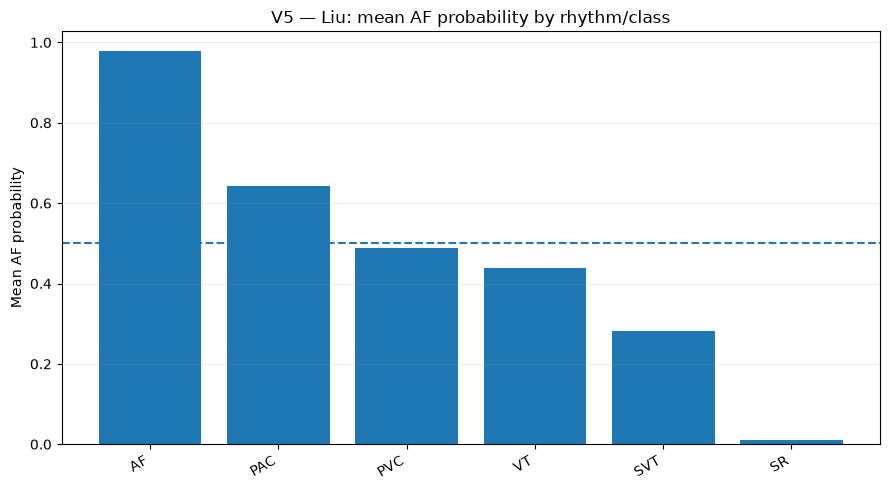

In [11]:
# ------------------------------------------------------------------
# PeakDet PAC/PVC: hard-negative only.
# There is no positive AF class here, so AUROC/PR-AUC is not meaningful.
# ------------------------------------------------------------------

peak_spec = v5_inventory[v5_inventory["dataset"] == "PeakDet PAC/PVC"]

if peak_spec.empty or not bool(peak_spec.iloc[0]["exists"]):
    print("PeakDet V5 prediction file chưa có ở canonical path.")
else:
    peak_file = REPO / peak_spec.iloc[0]["file"]
    peak = pd.read_csv(peak_file, low_memory=False)
    prob_col = infer_probability_column(peak)

    print("file:", peak_file)
    print("probability column:", prob_col)
    print("rows:", len(peak))

    if prob_col is None:
        print("Không tìm thấy AF probability column.")
    else:
        p = pd.to_numeric(peak[prob_col], errors="coerce").dropna()
        thresholds = np.array([0.5, 0.7, 0.8, 0.9, 0.95])
        fpr = np.array([(p >= t).mean() for t in thresholds])

        fig = plt.figure(figsize=(7, 5))
        plt.plot(thresholds, fpr, marker="o")
        plt.xlabel("AF probability threshold")
        plt.ylabel("PAC/PVC window false-positive rate")
        plt.title("V5 PeakDet PAC/PVC hard-negative challenge")
        plt.ylim(0, max(0.55, float(fpr.max()) + 0.05))
        plt.grid(alpha=0.25)
        plt.show()

        fig = plt.figure(figsize=(8, 5))
        plt.hist(p, bins=25, alpha=0.7)
        plt.axvline(0.5, linestyle="--", label="threshold 0.5")
        plt.axvline(0.9, linestyle="--", label="threshold 0.9")
        plt.xlabel("V5 AF probability")
        plt.ylabel("PAC/PVC windows")
        plt.title("V5 PeakDet probability distribution")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

        display(pd.DataFrame({
            "threshold": thresholds,
            "false_positive_windows": [(p >= t).sum() for t in thresholds],
            "window_FPR": fpr,
        }))

# ------------------------------------------------------------------
# Optional class/rhythm breakdown for external datasets.
# This helps visualize why PAC/PVC is a harder negative than NSR/SR.
# ------------------------------------------------------------------

for dataset in ["PulseWatch", "Liu"]:
    if dataset not in dataset_frames:
        continue

    d = dataset_frames[dataset]["df"]
    prob_col = dataset_frames[dataset]["prob_col"]

    group_col = None
    for c in ["class_name", "rhythm"]:
        if c in d.columns:
            group_col = c
            break

    if group_col is None:
        continue

    g = (
        d.groupby(group_col, dropna=False)[prob_col]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

    print("\n" + "="*90)
    print(f"{dataset} probability by {group_col}")
    display(g)

    fig = plt.figure(figsize=(9, 5))
    plt.bar(g[group_col].astype(str), g["mean"])
    plt.axhline(0.5, linestyle="--")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Mean AF probability")
    plt.title(f"V5 — {dataset}: mean AF probability by rhythm/class")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


## 9. V5 interpretation checklist

Khi đọc notebook:

- Đừng chỉ nhìn AUROC cao.
- Xem PR-AUC khi class imbalance mạnh.
- Xem probability distribution để thấy overlap.
- Xem confusion @0.5 chỉ như một operating point.
- **PulseWatch phải được quy về AF-vs-all trước khi dùng binary metrics.**
- PeakDet PAC/PVC là all-negative challenge nên dùng FPR theo threshold, không dùng AUROC/PR-AUC.
- Với PAC/PVC, đây là **hard-negative** problem chứ không phải chỉ AF-vs-normal.
- Nếu dùng subject-level alert, V5 notebook này chưa phải nơi kết luận temporal performance; temporal protocol sạch nằm ở V6 locked notebook.


## 10. Export figures

In [12]:
FIG_DIR = REPO / "notebooks" / "figures_v5"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Nếu muốn lưu figure, gọi plt.savefig(...) trước plt.show().")
print("Suggested output:", FIG_DIR)

Nếu muốn lưu figure, gọi plt.savefig(...) trước plt.show().
Suggested output: /home/phuc/Documents/HealthSense_rungtamnhi/notebooks/figures_v5
